<a href="https://colab.research.google.com/github/daniivelascoo/ifp-programacion-ia/blob/main/Teoria_2_3_A_Escalado_Datos_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Teoría Bloque A: El Gigante y la Hormiga (Escalado)
**Sprint 2.3 - Ingeniería de Datos Avanzada**

Muchos algoritmos de IA (como KNN, SVM o Redes Neuronales) calculan **distancias**.
Si tienes una columna con valores gigantes (ej: Salario anual) y otra con valores pequeños (ej: Edad), la IA pensará que el Salario es lo único que importa y la Edad es ruido.

Para evitarlo, debemos **Escalar** los datos.

### 🎯 Objetivos:
1.  **El Problema:** Visualizar datos con escalas dispares.
2.  **Normalización (`MinMaxScaler`):** Aplastar todo entre 0 y 1.
3.  **Estandarización (`StandardScaler`):** Centrar en 0 (La favorita de la IA).

## 1. El Problema de las Escalas

Vamos a crear un dataset de empleados.
*   **Edad:** Rango 20 - 60.
*   **Salario:** Rango 20.000 - 90.000.

Matemáticamente, una diferencia de 1 año (de 20 a 21) es un "1".
Una diferencia de 1 euro (de 20.000 a 20.001) es un "1".
¡Pero en la vida real 1 año es mucho cambio y 1 euro no es nada! La IA no lo sabe.

--- Datos Originales ---


,edad,salario
0,20,20000
1,30,30000
2,40,40000
3,50,80000
4,60,90000


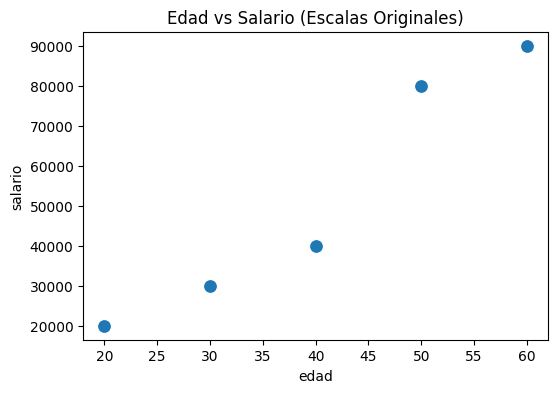

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datos sintéticos
df = pd.DataFrame({
    'edad':    [20, 30, 40, 50, 60],
    'salario': [20000, 30000, 40000, 80000, 90000]
})

print("--- Datos Originales ---")
display(df)

# Visualizamos
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='edad', y='salario', s=100)
plt.title("Edad vs Salario (Escalas Originales)")
plt.show()

# Fíjate en los ejes: El eje Y va de 20k a 90k. El eje X de 20 a 60.
# La "distancia" vertical es inmensa comparada con la horizontal.

## 2. Normalización (MinMaxScaler)

Esta técnica transforma los datos para que el mínimo sea **0** y el máximo sea **1**.
*   **Ventaja:** Mantiene la distribución exacta. Muy útil para Imágenes (píxeles 0-255).
*   **Desventaja:** Si hay un outlier gigante, el resto de datos se "aplastan" en un rincón.

In [2]:
from sklearn.preprocessing import MinMaxScaler

# 1. INSTANCIAR
mms = MinMaxScaler()

# 2. FIT & TRANSFORM
# fit: Calcula el Mínimo y el Máximo de cada columna.
# transform: Aplica la fórmula matemática.
df_norm = mms.fit_transform(df) # TODO: Usa fit_transform

# Lo convertimos a DataFrame para verlo bonito (sklearn devuelve arrays de numpy)
df_norm = pd.DataFrame(df_norm, columns=df.columns)

print("--- Datos Normalizados (MinMax) ---")
display(df_norm)

# Fíjate: El 20 años ahora es 0.0. El 60 años es 1.0.
# El salario 20000 es 0.0. El 90000 es 1.0.
# ¡Ahora ambas columnas tienen el mismo peso!

--- Datos Normalizados (MinMax) ---


,edad,salario
0,0.00,0.000000
1,0.25,0.142857
2,0.50,0.285714
3,0.75,0.857143
4,1.00,1.000000


## 3. Estandarización (StandardScaler)

Esta es la técnica reina en Machine Learning clásico.
Transforma los datos para que tengan:
*   **Media = 0**
*   **Desviación Típica = 1**

Los valores resultantes suelen estar entre -3 y 3.
Es más robusta a outliers que el MinMax.

In [3]:
from sklearn.preprocessing import StandardScaler

# 1. INSTANCIAR
scaler = StandardScaler() # TODO: Llama a StandardScaler

# 2. FIT & TRANSFORM
df_std = scaler.fit_transform(df)

# Convertir a DataFrame
df_std = pd.DataFrame(df_std, columns=df.columns)

print("--- Datos Estandarizados (StandardScaler) ---")
display(df_std)

# Fíjate:
# La media (aprox 40 años o 52k salario) estará cerca de 0.
# Los valores bajos son negativos.

--- Datos Estandarizados (StandardScaler) ---


,edad,salario
0,-1.414214,-1.148733
1,-0.707107,-0.789754
2,0.000000,-0.430775
3,0.707107,1.005141
4,1.414214,1.364121


## 4. Comparativa Visual

Vamos a ver cómo cambian los ejes, aunque la "forma" de los datos se mantiene.

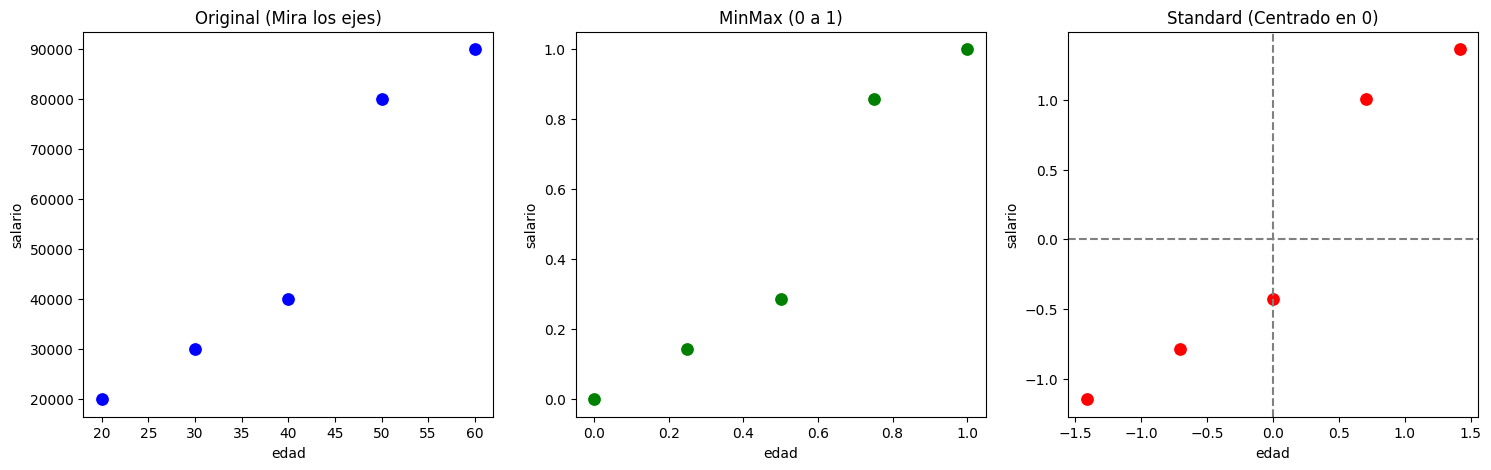

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Original
sns.scatterplot(data=df, x='edad', y='salario', ax=ax1, s=100, color='blue')
ax1.set_title("Original (Mira los ejes)")

# MinMax
sns.scatterplot(data=df_norm, x='edad', y='salario', ax=ax2, s=100, color='green')
ax2.set_title("MinMax (0 a 1)")

# Standard
sns.scatterplot(data=df_std, x='edad', y='salario', ax=ax3, s=100, color='red')
ax3.set_title("Standard (Centrado en 0)")
plt.axvline(x=0, color='gray', linestyle='--') # Línea del 0
plt.axhline(y=0, color='gray', linestyle='--') # Línea del 0

plt.show()